In [1]:
import sys
import torch
sys.path.insert(0, r"D:\Projects\ODM Project")

from utils.iou       import compute_iou, compute_iou_single
from utils.nms       import apply_nms, apply_nms_per_class
from utils.box_utils import (xyxy_to_xywh, xywh_to_xyxy,
                              xyxy_to_cxcywh, clip_boxes_to_image)
from utils.metrics   import compute_map
from utils.visualization import visualize_predictions
from dataset.coco_dataset import LABEL_TO_NAME

print("All utilities imported successfully!")

All utilities imported successfully!


In [3]:
# Test IoU with known values
boxes_a = torch.tensor([
    [0.,  0., 10., 10.],   # box 1
    [5.,  5., 15., 15.],   # box 2
    [20., 20., 30., 30.],  # box 3 (no overlap with box_b[0])
])

boxes_b = torch.tensor([
    [0., 0., 10., 10.],    # perfect match with box 1
])

iou_matrix = compute_iou(boxes_a, boxes_b)

print("=== IoU Test ===\n")
print(f"boxes_a shape : {boxes_a.shape}")
print(f"boxes_b shape : {boxes_b.shape}")
print(f"IoU matrix shape : {iou_matrix.shape}  (expected [3,1])\n")
print(f"IoU(box1, box_b) = {iou_matrix[0,0]:.4f}  (expected 1.0 — perfect overlap)")
print(f"IoU(box2, box_b) = {iou_matrix[1,0]:.4f}  (expected ~0.14 — partial overlap)")
print(f"IoU(box3, box_b) = {iou_matrix[2,0]:.4f}  (expected 0.0 — no overlap)")

=== IoU Test ===

boxes_a shape : torch.Size([3, 4])
boxes_b shape : torch.Size([1, 4])
IoU matrix shape : torch.Size([3, 1])  (expected [3,1])

IoU(box1, box_b) = 1.0000  (expected 1.0 — perfect overlap)
IoU(box2, box_b) = 0.1429  (expected ~0.14 — partial overlap)
IoU(box3, box_b) = 0.0000  (expected 0.0 — no overlap)


=== NMS Test ===

Before NMS: 4 boxes
After  NMS: 2 boxes  (indices kept: [0, 3])

Kept boxes:
  [0] score=0.95  box=[100.0, 100.0, 300.0, 300.0]
  [3] score=0.91  box=[400.0, 100.0, 600.0, 300.0]


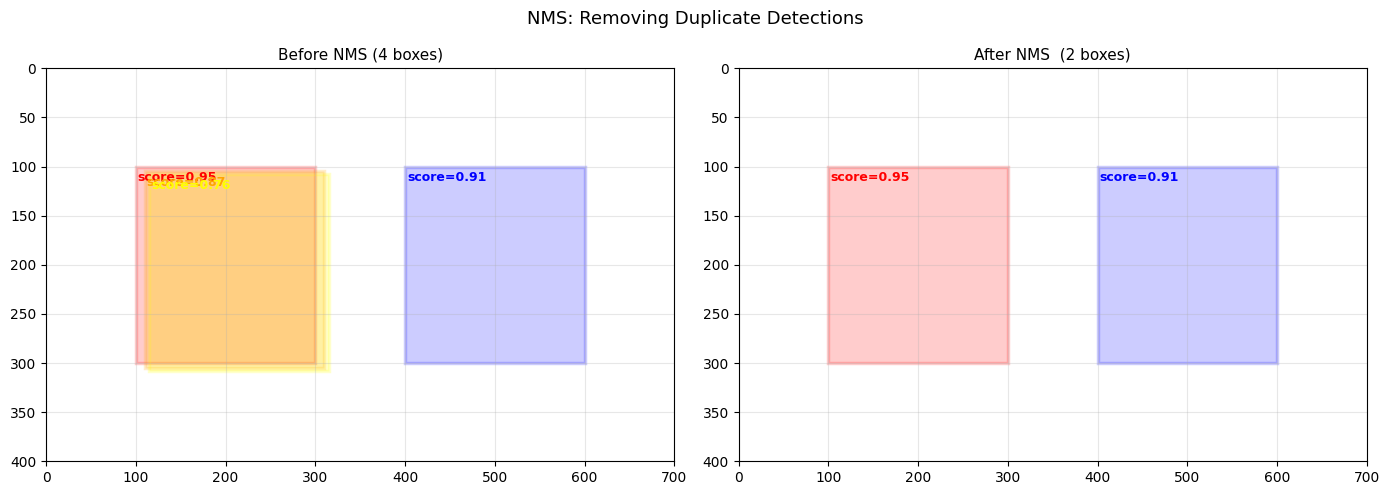

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Simulate overlapping detections of the same object
boxes = torch.tensor([
    [100., 100., 300., 300.],  # score 0.95 — best box
    [110., 105., 310., 305.],  # score 0.87 — very similar, duplicate
    [115., 108., 315., 308.],  # score 0.76 — another duplicate
    [400., 100., 600., 300.],  # score 0.91 — different object, keep
])
scores = torch.tensor([0.95, 0.87, 0.76, 0.91])

keep = apply_nms(boxes, scores, iou_thresh=0.5)

print("=== NMS Test ===\n")
print(f"Before NMS: {len(boxes)} boxes")
print(f"After  NMS: {len(keep)} boxes  (indices kept: {keep.tolist()})")
print(f"\nKept boxes:")
for idx in keep:
    print(f"  [{idx}] score={scores[idx]:.2f}  box={boxes[idx].tolist()}")

# Visualise NMS effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_before = ["red", "orange", "yellow", "blue"]
colors_after  = ["red", "blue"]

for ax, title, show_indices in [
    (axes[0], "Before NMS (4 boxes)", range(len(boxes))),
    (axes[1], "After NMS  (2 boxes)", keep.tolist()),
]:
    ax.set_xlim(0, 700); ax.set_ylim(0, 400)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11)

    for i in show_indices:
        x1,y1,x2,y2 = boxes[i].tolist()
        color = colors_before[i]
        rect  = patches.Rectangle((x1,y1), x2-x1, y2-y1,
                    linewidth=2.5, edgecolor=color, facecolor=color, alpha=0.2)
        ax.add_patch(rect)
        ax.text(x1+2, y1+15, f"score={scores[i]:.2f}", fontsize=9,
                color=color, fontweight="bold")
    ax.grid(True, alpha=0.3)

plt.suptitle("NMS: Removing Duplicate Detections", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
print("=== Box Format Conversion Test ===\n")

original_xyxy = torch.tensor([
    [50., 30., 200., 250.],
    [10., 20., 100., 150.],
])

# xyxy -> xywh -> xyxy (should be identical)
xywh      = xyxy_to_xywh(original_xyxy)
back_xyxy = xywh_to_xyxy(xywh)

print(f"Original xyxy :\n{original_xyxy}\n")
print(f"Converted xywh:\n{xywh}\n")
print(f"Back to xyxy  :\n{back_xyxy}\n")
print(f"Round-trip correct: {torch.allclose(original_xyxy, back_xyxy)}")

# Test clip - use regular minus sign (-)
oversized = torch.tensor([[-10., -5., 850., 650.]])
clipped   = clip_boxes_to_image(oversized, image_size=(600, 800))
print(f"\nOversized box : {oversized.tolist()}")
print(f"Clipped box   : {clipped.tolist()}  (clipped to 800x600 image)")

=== Box Format Conversion Test ===

Original xyxy :
tensor([[ 50.,  30., 200., 250.],
        [ 10.,  20., 100., 150.]])

Converted xywh:
tensor([[ 50.,  30., 150., 220.],
        [ 10.,  20.,  90., 130.]])

Back to xyxy  :
tensor([[ 50.,  30., 200., 250.],
        [ 10.,  20., 100., 150.]])

Round-trip correct: True

Oversized box : [[-10.0, -5.0, 850.0, 650.0]]
Clipped box   : [[0.0, 0.0, 800.0, 600.0]]  (clipped to 800x600 image)


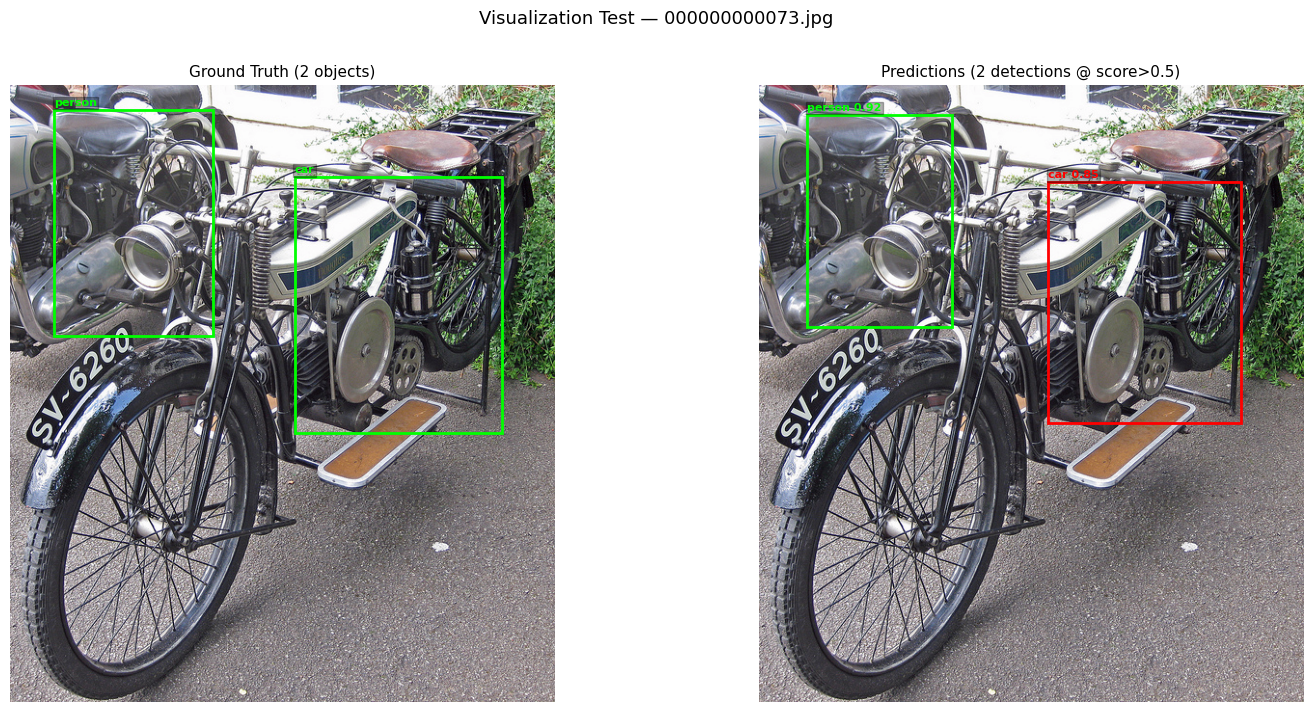

In [ ]:
import os
from PIL import Image
import torchvision.transforms.functional as F

# Load a real image from your dataset
img_dir  = r"D:\Projects\ODM Project\People_vehicles dataset\filtered_images"
img_name = os.listdir(img_dir)[5]
img_path = os.path.join(img_dir, img_name)

img_tensor = F.normalize(
    F.to_tensor(Image.open(img_path).convert("RGB")),
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

H, W = img_tensor.shape[1], img_tensor.shape[2]

# Fake some predictions to test visualization
fake_predictions = {
    "boxes":  torch.tensor([[50., 30., 200., 250.],
                             [300., 100., 500., 350.]]),
    "labels": torch.tensor([1, 3]),    # person, car
    "scores": torch.tensor([0.92, 0.85]),
}

fake_ground_truth = {
    "boxes":  torch.tensor([[45., 25., 210., 260.],
                             [295., 95., 510., 360.]]),
    "labels": torch.tensor([1, 3]),
}

visualize_predictions(
    image        = img_tensor,
    predictions  = fake_predictions,
    ground_truth = fake_ground_truth,
    label_names  = LABEL_TO_NAME,
    score_thresh = 0.5,
    title        = f"Visualization Test — {img_name}",
)

In [8]:
checks = {}

# IoU correctness
iou_perfect  = compute_iou_single(
    torch.tensor([0., 0., 10., 10.]),
    torch.tensor([0., 0., 10., 10.])
)
iou_no_overlap = compute_iou_single(
    torch.tensor([0., 0., 10., 10.]),
    torch.tensor([20., 20., 30., 30.])
)
checks["IoU perfect overlap = 1.0"]   = abs(iou_perfect - 1.0) < 1e-4
checks["IoU no overlap = 0.0"]        = abs(iou_no_overlap) < 1e-4

# NMS reduces boxes
boxes  = torch.tensor([[0.,0.,10.,10.],[1.,1.,11.,11.],[50.,50.,60.,60.]])
scores = torch.tensor([0.9, 0.8, 0.7])
keep   = apply_nms(boxes, scores, iou_thresh=0.5)
checks["NMS removes duplicates"]      = len(keep) == 2

# Box conversions are lossless
orig  = torch.tensor([[10., 20., 100., 150.]])
checks["Box conversion round-trip"]   = torch.allclose(
    orig, xywh_to_xyxy(xyxy_to_xywh(orig))
)

# Clip keeps boxes inside image
oversized = torch.tensor([[-10., -5., 850., 650.]])
clipped   = clip_boxes_to_image(oversized, (600, 800))
checks["Clip boxes to image boundary"] = (
    clipped[0, 0] >= 0 and
    clipped[0, 1] >= 0 and
    clipped[0, 2] <= 800 and
    clipped[0, 3] <= 600
)

# IoU matrix shape
iou_mat = compute_iou(
    torch.rand(5, 4),
    torch.rand(3, 4)
)
checks["IoU matrix shape correct"]    = iou_mat.shape == (5, 3)

print("=== Step 5 Checklist ===\n")
all_passed = True
for check, passed in checks.items():
    icon = "✅" if passed else "❌"
    print(f"  {icon}  {check}")
    if not passed:
        all_passed = False

print()
if all_passed:
    print("All checks passed — ready for Step 6 (Training Loop)!")
else:
    print("Fix the failing checks before moving on.")

=== Step 5 Checklist ===

  ✅  IoU perfect overlap = 1.0
  ✅  IoU no overlap = 0.0
  ✅  NMS removes duplicates
  ✅  Box conversion round-trip
  ✅  Clip boxes to image boundary
  ✅  IoU matrix shape correct

All checks passed — ready for Step 6 (Training Loop)!
